<h3>=> Libraries Import</h3>

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


<h3>=> Dataset Load</h3>

In [40]:
df=pd.read_csv('ADSI_Table_1A.2.csv')

<h3>=> Data Understanding</h3>

In [41]:
df.head()

,Sl. No.,State/UT/City,Road Accidents - Cases,Road Accidents - Injured,Road Accidents - Died,Railway Accidents - Cases,Railway Accidents - Injured,Railway Accidents - Died,Railway Crossing Accidents - Cases,Railway Crossing Accidents - Injured,Railway Crossing Accidents - Died,Total Traffic Accidents - Cases,Total Traffic Accidents - Injured,Total Traffic Accidents - Died
0,1,Andhra Pradesh,21070,21340,8293,1029,0,1037,0,0,0,22099,21340,9330
1,2,Arunachal Pradesh,215,177,152,0,0,0,0,0,0,215,177,152
2,3,Assam,7028,5679,3060,689,0,693,22,0,22,7739,5679,3775
3,4,Bihar,10801,7068,8898,1444,6,1446,52,0,53,12297,7074,10397
4,5,Chhattisgarh,13091,11459,5890,429,21,429,4,0,4,13524,11480,6323


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Sl. No.                               93 non-null     object
 1   State/UT/City                         93 non-null     object
 2   Road Accidents - Cases                93 non-null     int64 
 3   Road Accidents - Injured              93 non-null     int64 
 4   Road Accidents - Died                 93 non-null     int64 
 5   Railway Accidents - Cases             93 non-null     int64 
 6   Railway Accidents - Injured           93 non-null     int64 
 7   Railway Accidents - Died              93 non-null     int64 
 8   Railway Crossing Accidents - Cases    93 non-null     int64 
 9   Railway Crossing Accidents - Injured  93 non-null     int64 
 10  Railway Crossing Accidents - Died     93 non-null     int64 
 11  Total Traffic Accidents - Cases   

In [43]:
df.shape

(93, 14)

<h3>=> Data Cleaning</h3>

In [44]:
df.isnull().sum()

Sl. No.                                 0
State/UT/City                           0
Road Accidents - Cases                  0
Road Accidents - Injured                0
Road Accidents - Died                   0
Railway Accidents - Cases               0
Railway Accidents - Injured             0
Railway Accidents - Died                0
Railway Crossing Accidents - Cases      0
Railway Crossing Accidents - Injured    0
Railway Crossing Accidents - Died       0
Total Traffic Accidents - Cases         0
Total Traffic Accidents - Injured       0
Total Traffic Accidents - Died          0
dtype: int64

In [45]:
df = df[~df['State/UT/City'].str.contains('Total', case=False, na=False)]


In [46]:
df.rename(columns={
    'State/UT/City': 'Region_Name',
    'Sl. No.': 'Sl_No'
}, inplace=True)


In [47]:
uts = [
    'Delhi','Jammu & Kashmir','Ladakh','Chandigarh',
    'Puducherry','Andaman & Nicobar Islands',
    'Dadra & Nagar Haveli and Daman & Diu',
    'Lakshadweep'
]


In [48]:
df['Sl_No'] = pd.to_numeric(df['Sl_No'], errors='coerce')


In [49]:
df['Region_Type'] = 'State'

df.loc[(df['Sl_No'] >= 29) & (df['Sl_No'] <= 36), 'Region_Type'] = 'UT'
df.loc[df['Sl_No'] >= 37, 'Region_Type'] = 'City'


In [50]:
df[['Sl_No','Region_Name','Region_Type']].head(40)


,Sl_No,Region_Name,Region_Type
0,1,Andhra Pradesh,State
1,2,Arunachal Pradesh,State
2,3,Assam,State
3,4,Bihar,State
4,5,Chhattisgarh,State
5,6,Goa,State
6,7,Gujarat,State
7,8,Haryana,State
8,9,Himachal Pradesh,State
9,10,Jharkhand,State


In [51]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 91
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Sl_No                                 89 non-null     int64 
 1   Region_Name                           89 non-null     object
 2   Road Accidents - Cases                89 non-null     int64 
 3   Road Accidents - Injured              89 non-null     int64 
 4   Road Accidents - Died                 89 non-null     int64 
 5   Railway Accidents - Cases             89 non-null     int64 
 6   Railway Accidents - Injured           89 non-null     int64 
 7   Railway Accidents - Died              89 non-null     int64 
 8   Railway Crossing Accidents - Cases    89 non-null     int64 
 9   Railway Crossing Accidents - Injured  89 non-null     int64 
 10  Railway Crossing Accidents - Died     89 non-null     int64 
 11  Total Traffic Accidents - Cases       8

In [52]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('-', '')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 91
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   sl_no                                89 non-null     int64 
 1   region_name                          89 non-null     object
 2   road_accidents__cases                89 non-null     int64 
 3   road_accidents__injured              89 non-null     int64 
 4   road_accidents__died                 89 non-null     int64 
 5   railway_accidents__cases             89 non-null     int64 
 6   railway_accidents__injured           89 non-null     int64 
 7   railway_accidents__died              89 non-null     int64 
 8   railway_crossing_accidents__cases    89 non-null     int64 
 9   railway_crossing_accidents__injured  89 non-null     int64 
 10  railway_crossing_accidents__died     89 non-null     int64 
 11  total_traffic_accidents__cases       89 non-null    

In [53]:
df.columns = df.columns.str.lower().str.replace('__', '_')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89 entries, 0 to 91
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   sl_no                               89 non-null     int64 
 1   region_name                         89 non-null     object
 2   road_accidents_cases                89 non-null     int64 
 3   road_accidents_injured              89 non-null     int64 
 4   road_accidents_died                 89 non-null     int64 
 5   railway_accidents_cases             89 non-null     int64 
 6   railway_accidents_injured           89 non-null     int64 
 7   railway_accidents_died              89 non-null     int64 
 8   railway_crossing_accidents_cases    89 non-null     int64 
 9   railway_crossing_accidents_injured  89 non-null     int64 
 10  railway_crossing_accidents_died     89 non-null     int64 
 11  total_traffic_accidents_cases       89 non-null     int64 
 12  t

In [54]:
df.duplicated().sum()

np.int64(0)

<h3>=> Cleaned Data Save</h3>

In [55]:
df.to_csv("cleaned_traffic_accident_data_3.csv", index=False)


<h3>=> EDA(Exploratory Data Analysis)</h3>

**State-wise total accidents (Top 10)**

// State-wise Total Traffic Accidents (Top 10)

-> This visualization highlights the states contributing the highest number of traffic accidents, helping identify high-burden regions.


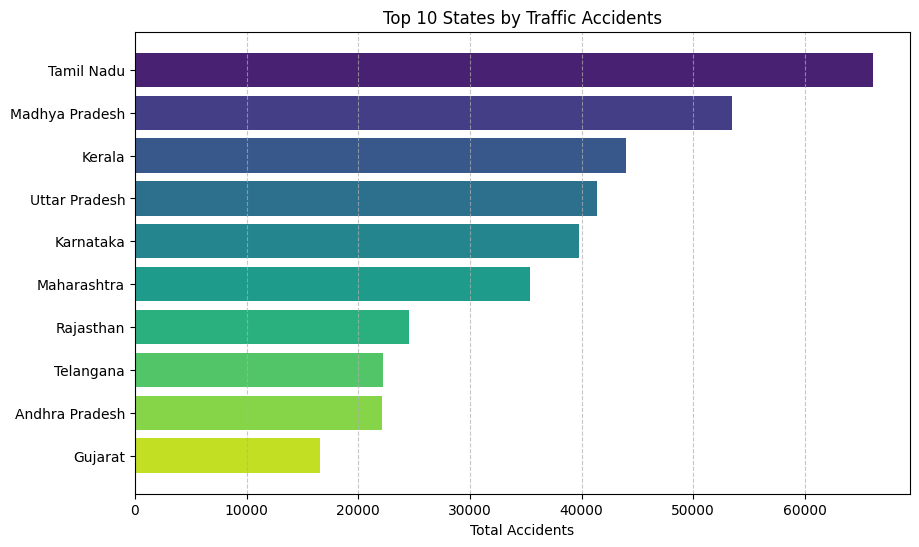

In [56]:
state_df = df[df['region_type'] == 'State']
top_states = state_df.sort_values('total_traffic_accidents_cases', ascending=False).head(10)
top_states[['region_name','total_traffic_accidents_cases']]
plt.figure(figsize=(10,6))
plt.barh(top_states['region_name'],top_states['total_traffic_accidents_cases'],color=sns.color_palette('viridis', 10))
plt.xlabel('Total Accidents')
plt.title('Top 10 States by Traffic Accidents')
plt.gca().invert_yaxis()
plt.grid(axis='x',linestyle='--',alpha=0.7)
plt.show()

**Severity Rate (Deaths / Accidents)**

// Accident Severity Rate by State

-> Severity rate helps identify states where accidents are more likely to result in fatalities.


In [57]:
df['severity_rate'] = (
    df['total_traffic_accidents_died'] /
    df['total_traffic_accidents_cases']
)



**Top 10 States by Severity Rate**

// Top 10 States by Accident Severity

-> This chart reveals states with disproportionately high fatality rates per accident.



In [58]:
df['severity_rate'] = (
    df['total_traffic_accidents_died'] /
    df['total_traffic_accidents_cases']
)


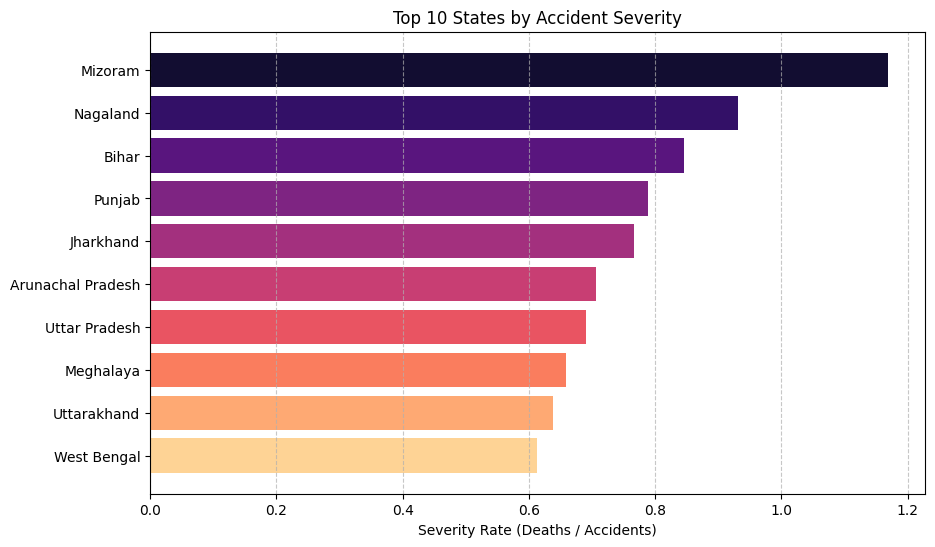

In [59]:
state_df = df[df['region_type'] == 'State']
top_severe_states = (state_df.sort_values('severity_rate', ascending=False).head(10))
top_severe_states[['region_name','severity_rate']]
plt.figure(figsize=(10,6))
plt.barh(top_severe_states['region_name'],top_severe_states['severity_rate'],color=sns.color_palette('magma', 10))
plt.xlabel('Severity Rate (Deaths / Accidents)')
plt.title('Top 10 States by Accident Severity')
plt.gca().invert_yaxis()
plt.grid(axis='x',linestyle='--',alpha=0.7)
plt.show()

**Region Type Comparison (State vs UT vs City)**

// Average Traffic Accidents by Region Type

->This comparison shows how accident patterns differ between states, union territories, and cities.

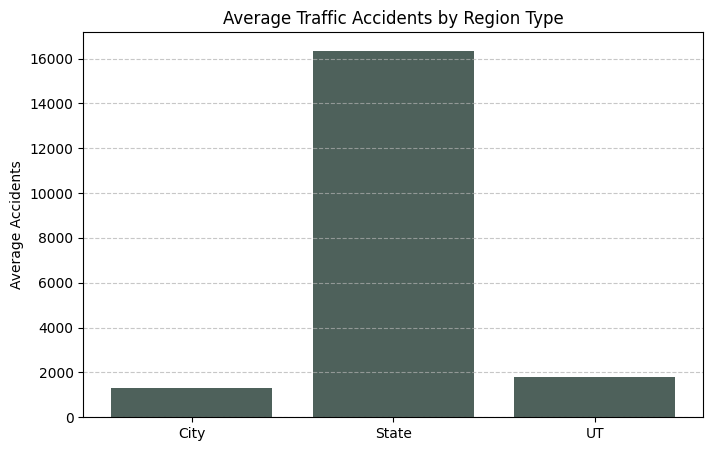

In [60]:
region_summary = df.groupby('region_type')[['total_traffic_accidents_cases',
    'total_traffic_accidents_died']].mean()
region_summary
plt.figure(figsize=(8,5))
plt.bar(region_summary.index,
    region_summary['total_traffic_accidents_cases'],
    color='#4E615B')
plt.ylabel('Average Accidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Average Traffic Accidents by Region Type')
plt.show()


**Accident Type Contribution (Bar Chart)**

// Contribution of Accident Types

-> This chart compares the frequency of road, railway, and railway crossing accidents.


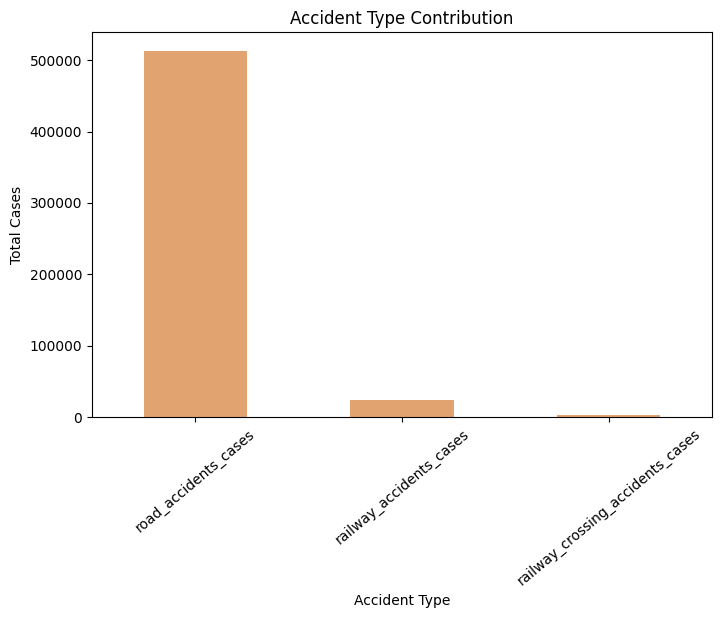

In [61]:
accident_type_totals = df[[
    'road_accidents_cases',
    'railway_accidents_cases',
    'railway_crossing_accidents_cases'
]].sum()
accident_type_totals
plt.figure(figsize=(8,5))
accident_type_totals.plot(kind='bar', color="#E1A36F")
plt.ylabel('Total Cases')
plt.xlabel('Accident Type')
plt.xticks(rotation=40)
plt.title('Accident Type Contribution')
plt.show()

**Top 10 Accident-Prone Cities**

// Top 10 Cities by Traffic Accidents

-> This analysis identifies cities with the highest concentration of traffic accidents.



In [62]:
city_df = df[df['region_type'] == 'City']

top_cities = city_df.sort_values(
    'total_traffic_accidents_cases', ascending=False
).head(10)

top_cities[['region_name','total_traffic_accidents_cases']]

,region_name,total_traffic_accidents_cases
49,Delhi (city),6183
44,Bengaluru,3822
47,Chennai,3452
56,Indore,3334
45,Bhopal,2855
58,Jaipur,2840
55,Hyderabad,2516
57,Jabalpur,2460
63,Kochi,2454
85,Thrissur,2374


-> Tamil Nadu and Maharashtra report the highest number of road accidents.

-> Severity rate is higher in some low-accident states, indicating higher fatality risk.

-> Road accidents contribute the majority of traffic fatalities compared to railway accidents.

-> Cities show concentrated accident hotspots compared to states and UTs.

**Correlation Analysis (ADVANCED EDA)**

// Correlation Analysis of Accident Metrics

-> The heatmap shows strong positive correlations between accident cases and fatalities, especially for road accidents.


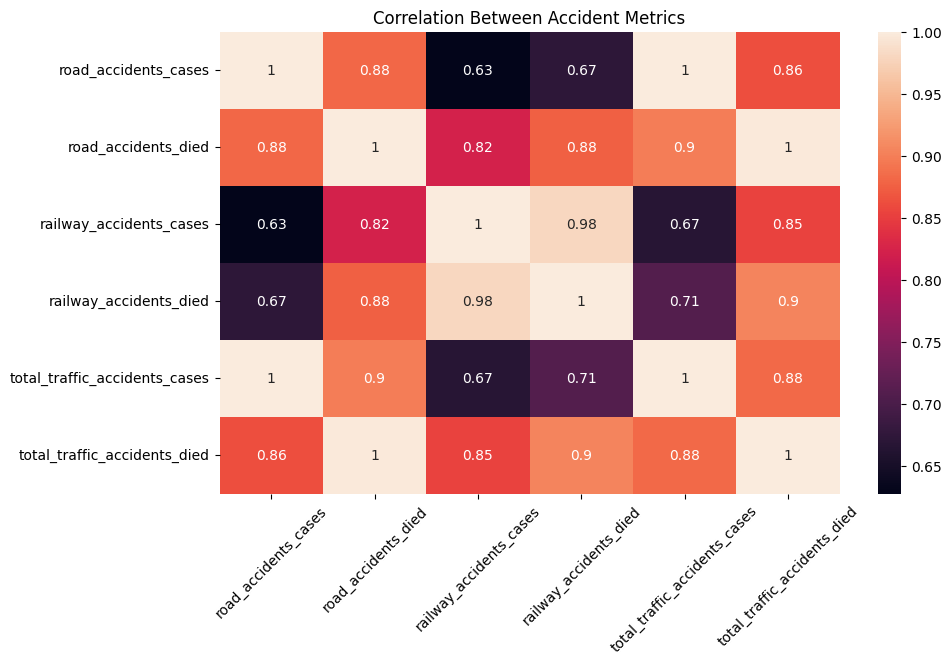

In [63]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['road_accidents_cases',
        'road_accidents_died',
        'railway_accidents_cases',
        'railway_accidents_died',
        'total_traffic_accidents_cases',
        'total_traffic_accidents_died'
    ]].corr(),
    annot=True)
plt.title('Correlation Between Accident Metrics')
plt.xticks(rotation=45)
plt.show()

**Scatter Plot – Accidents vs Deaths**

//Relationship Between Accidents and Fatalities

This scatter plot shows that higher accident counts generally lead to higher fatalities, with some regions showing disproportionate risk.


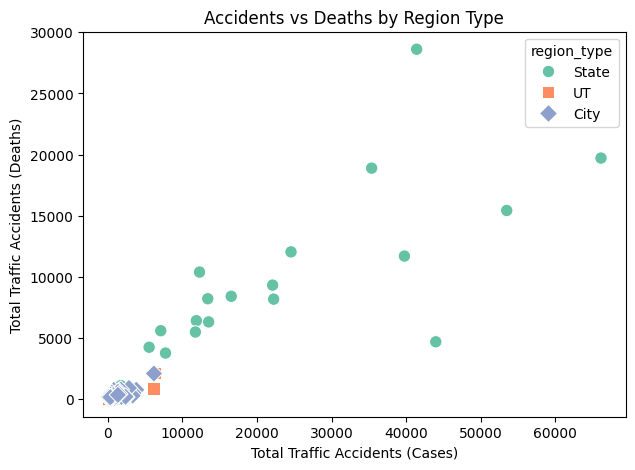

In [64]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x='total_traffic_accidents_cases',y='total_traffic_accidents_died',hue='region_type',style='region_type',markers={'State': 'o', 'UT': 's', 'City': 'D'}, 
    palette='Set2',                   
    data=df,
    s=80       
)
plt.title('Accidents vs Deaths by Region Type')
plt.xlabel('Total Traffic Accidents (Cases)')
plt.ylabel('Total Traffic Accidents (Deaths)')
plt.show()


**Accident Type Share (Pie Chart)**


// Proportion of Accident Types

-> The pie chart highlights the overwhelming dominance of road accidents in total traffic incidents.



In [65]:

city_df = df[df['region_type'] == 'City']
city_totals = city_df.groupby('region_name')['total_traffic_accidents_cases'].sum()
city_totals = city_totals.sort_values(ascending=False).head(5)

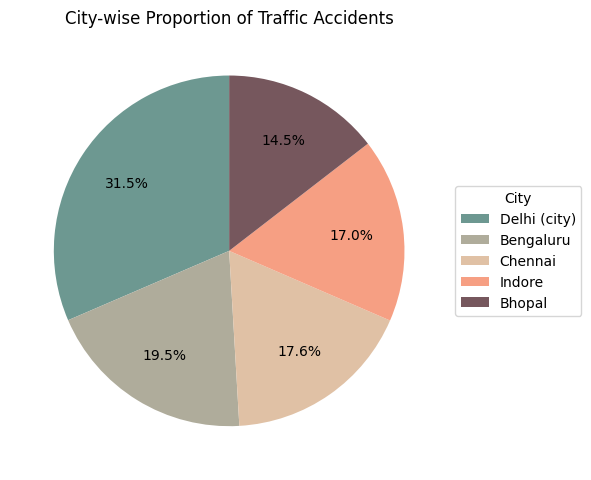

In [66]:
plt.figure(figsize=(6,6))
def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{pct:.1f}%' if pct > 10 else ''
    return my_format
plt.pie(city_totals,autopct=autopct_format(city_totals),startangle=90,
    pctdistance=0.7,colors=["#6D9891", "#AFAC9B", "#E0C1A5", "#F69F83", "#76575D"])
plt.legend(city_totals.index,title="City",loc="center left",bbox_to_anchor=(1, 0.5))
plt.title('City-wise Proportion of Traffic Accidents')
plt.tight_layout()
plt.show()


<h3>=> Feature Engineering<h3>

In [67]:
df["fatality_rate"] = df["total_traffic_accidents_died"] / df["total_traffic_accidents_cases"].replace(0, 1)
df.head()

,sl_no,region_name,road_accidents_cases,road_accidents_injured,road_accidents_died,railway_accidents_cases,railway_accidents_injured,railway_accidents_died,railway_crossing_accidents_cases,railway_crossing_accidents_injured,railway_crossing_accidents_died,total_traffic_accidents_cases,total_traffic_accidents_injured,total_traffic_accidents_died,region_type,severity_rate,fatality_rate
0,1,Andhra Pradesh,21070,21340,8293,1029,0,1037,0,0,0,22099,21340,9330,State,0.422191,0.422191
1,2,Arunachal Pradesh,215,177,152,0,0,0,0,0,0,215,177,152,State,0.706977,0.706977
2,3,Assam,7028,5679,3060,689,0,693,22,0,22,7739,5679,3775,State,0.487789,0.487789
3,4,Bihar,10801,7068,8898,1444,6,1446,52,0,53,12297,7074,10397,State,0.845491,0.845491
4,5,Chhattisgarh,13091,11459,5890,429,21,429,4,0,4,13524,11480,6323,State,0.467539,0.467539


In [68]:
def severity_label(rate):
    if rate < 0.05:
        return "Low"
    elif rate < 0.10:
        return "Medium"
    else:
        return "High"

df["accident_severity"] = df["fatality_rate"].apply(severity_label)
df[["region_name", "fatality_rate", "accident_severity"]].head()



,region_name,fatality_rate,accident_severity
0,Andhra Pradesh,0.422191,High
1,Arunachal Pradesh,0.706977,High
2,Assam,0.487789,High
3,Bihar,0.845491,High
4,Chhattisgarh,0.467539,High


<h3>=> Model Building</h3>

**Accident Severity prediction model**

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

df = df.drop(columns=["sl_no", "region_name"])

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
X = df.drop("accident_severity", axis=1)
y = df["accident_severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100,max_depth=10, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accident Severity Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



Accident Severity Accuracy: 0.8888888888888888
[[16  0]
 [ 2  0]]
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        16
           1       0.00      0.00      0.00         2

    accuracy                           0.89        18
   macro avg       0.44      0.50      0.47        18
weighted avg       0.79      0.89      0.84        18



C:\Users\trushali\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\trushali\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\trushali\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

**High-Risk Accident State Prediction Model**

In [70]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df["high_risk"] = (df["fatality_rate"] > df["fatality_rate"].median()).astype(int)

X = df.drop(["fatality_rate", "high_risk"], axis=1)
y = df["high_risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100,max_depth=10,random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9444444444444444
[[10  1]
 [ 0  7]]
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.88      1.00      0.93         7

    accuracy                           0.94        18
   macro avg       0.94      0.95      0.94        18
weighted avg       0.95      0.94      0.94        18



<h3>=> Model Evaluation</h3>

**Accuracy**

The model achieved an accuracy of 0.94%, indicating that it correctly classified most regions into high-risk and low-risk categories based on accident severity.

In [71]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9444444444444444


**Confusion Matrix**

The confusion matrix shows the number of correct and incorrect predictions made by the model.
It helps understand how well the model distinguishes between high-risk and low-risk regions.

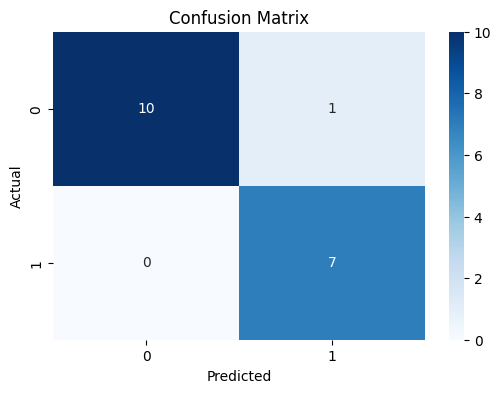

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


**Classification Report**

The classification report provides precision, recall, and F1-score, giving a detailed evaluation of the model’s performance beyond accuracy.

In [73]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       0.88      1.00      0.93         7

    accuracy                           0.94        18
   macro avg       0.94      0.95      0.94        18
weighted avg       0.95      0.94      0.94        18



<h3>=> Conclusion</h3>

In this project, traffic accident data was analyzed to identify high-risk regions.
Data cleaning and feature engineering were performed to improve data quality.
Exploratory data analysis helped uncover accident patterns across states, UTs, and cities.
A Random Forest classification model was trained to predict high-risk regions, achieving satisfactory performance.
This analysis can help policymakers focus on accident-prone areas and improve road safety measures.

<h3>=> Limitations</h3>

- The dataset is aggregated and does not include individual accident-level details.

- External factors such as weather, road condition, and traffic density were not included.

- Model performance may improve with more granular and recent data.

<h3>=> Future Scope</h3>

* The model can be enhanced using real-time accident data.

- Advanced models and additional features can be used for better prediction accuracy.

- The analysis can be extended to district-level accident prediction.

In [74]:
import pickle

# Model save
pickle.dump(model, open("accident_severity_model.pkl", "wb"))

print("accident_severity_model.pkl saved successfully")


accident_severity_model.pkl saved successfully


In [75]:
import pickle

pickle.dump(model, open("high_risk_model.pkl", "wb"))

print("high_risk_model.pkl saved successfully")


high_risk_model.pkl saved successfully
